# Exploration des datasets de détection de fraude

## Présentation des datasets

Ces datasets contiennent des transactions par carte de crédit réelles simulées entre **janvier 2019** et **juin 2020**, pour des clients aux États-Unis.

Deux fichiers sont disponibles :
- `fraudTrain.csv` — jeu d'entraînement (~1,3 M transactions)
- `fraudTest.csv` — jeu de test (~555 k transactions)

### Colonnes principales

| Colonne | Description |
|---|---|
| `trans_date_trans_time` | Date et heure de la transaction |
| `cc_num` | Numéro de carte de crédit (anonymisé) |
| `merchant` | Nom du marchand |
| `category` | Catégorie du marchand |
| `amt` | Montant de la transaction (USD) |
| `first`, `last` | Prénom et nom du titulaire |
| `gender` | Genre du titulaire (`M` / `F`) |
| `city`, `state`, `zip` | Localisation du titulaire |
| `lat`, `long` | Coordonnées GPS du titulaire |
| `city_pop` | Population de la ville |
| `job` | Profession du titulaire |
| `dob` | Date de naissance |
| `trans_num` | Identifiant unique de la transaction |
| `unix_time` | Timestamp UNIX de la transaction |
| `merch_lat`, `merch_long` | Coordonnées GPS du marchand |
| `is_fraud` | **Variable cible** : `1` = fraude, `0` = légitime |

## 1. Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
print("Librairies importées.")

Librairies importées.


## 2. Chargement des données

In [2]:
train = pd.read_csv(
    "../data/fraudTrain.csv", index_col=0, parse_dates=["trans_date_trans_time", "dob"]
)
test = pd.read_csv(
    "../data/fraudTest.csv", index_col=0, parse_dates=["trans_date_trans_time", "dob"]
)

print(f"Train : {train.shape[0]:>10,} lignes et {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:>10,} lignes et {test.shape[1]} colonnes")

Train :  1,296,675 lignes et 22 colonnes
Test  :    555,719 lignes et 22 colonnes


## 3. Exploration de base

In [3]:
print("dataset de train")
train.info()
print()
print("dataset de test")
test.info()

dataset de train
<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat             

In [4]:
print("Aperçu du jeu d'entraînement :")
train.head()

Aperçu du jeu d'entraînement :


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

summary = pd.DataFrame(
    {
        "Train (manquants)": missing_train,
        "Test (manquants)": missing_test,
    }
).query("`Train (manquants)` > 0 or `Test (manquants)` > 0")

if summary.empty:
    print("Aucune valeur manquante dans les deux datasets.")
else:
    display(summary)

Aucune valeur manquante dans les deux datasets.


### Statistiques descriptives des colonnes numériques clés

In [6]:
cols_num = ["amt", "city_pop", "lat", "long", "merch_lat", "merch_long"]
print("Statistiques descriptives – TRAIN")
train[cols_num].describe().T

Statistiques descriptives – TRAIN


,count,mean,std,min,25%,50%,75%,max
amt,1296675.0,70.351035,160.316039,1.000000,9.650000,47.520000,83.140000,2.894890e+04
city_pop,1296675.0,88824.440563,301956.360689,23.000000,743.000000,2456.000000,20328.000000,2.906700e+06
lat,1296675.0,38.537622,5.075808,20.027100,34.620500,39.354300,41.940400,6.669330e+01
long,1296675.0,-90.226335,13.759077,-165.672300,-96.798000,-87.476900,-80.158000,-6.795030e+01
merch_lat,1296675.0,38.537338,5.109788,19.027785,34.733572,39.365680,41.957164,6.751027e+01
merch_long,1296675.0,-90.226465,13.771091,-166.671242,-96.897276,-87.438392,-80.236796,-6.695090e+01


## 4. Distribution de la variable cible (`is_fraud`)

In [7]:
def fraud_summary(df, name):
    counts = df["is_fraud"].value_counts().sort_index()
    pct = df["is_fraud"].value_counts(normalize=True).sort_index() * 100
    result = pd.DataFrame(
        {
            "Nb transactions": counts.values,
            "Pourcentage (%)": pct.round(3).values,
        },
        index=["Légitimes (0)", "Fraudes (1)"],
    ).rename_axis(name)
    return result


display(fraud_summary(train, "TRAIN"))
display(fraud_summary(test, "TEST"))

,Nb transactions,Pourcentage (%)
TRAIN,,
Légitimes (0),1289169,99.421
Fraudes (1),7506,0.579


,Nb transactions,Pourcentage (%)
TEST,,
Légitimes (0),553574,99.614
Fraudes (1),2145,0.386


## 5. Analyse des montants (`amt`)

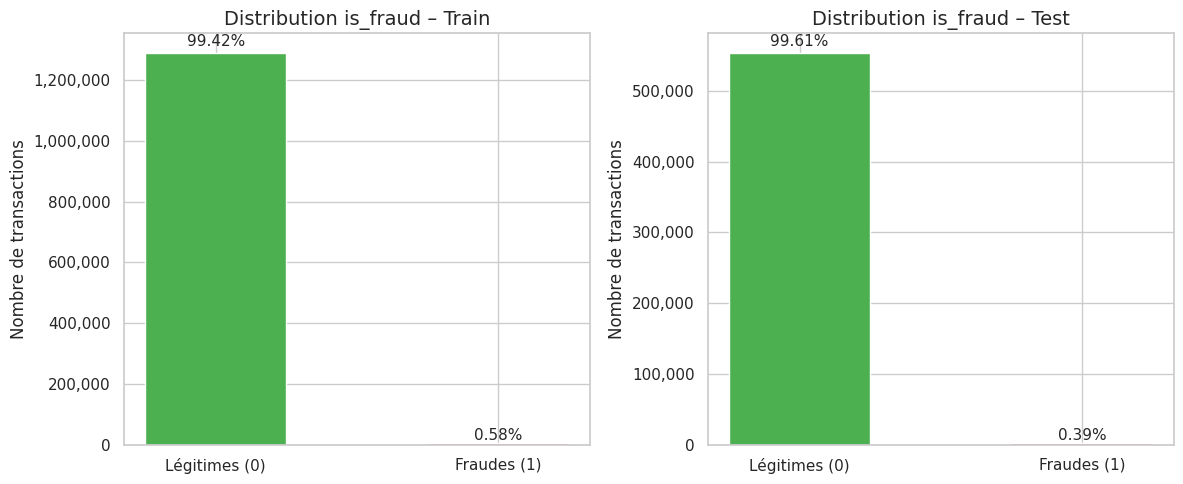

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Légitimes (0)", "Fraudes (1)"]

for ax, (df, name) in zip(axes, [(train, "Train"), (test, "Test")]):
    counts = df["is_fraud"].value_counts().sort_index()
    bars = ax.bar(
        labels, counts, color=["#4caf50", "#f44336"], edgecolor="white", width=0.5
    )
    ax.set_title(f"Distribution is_fraud – {name}")
    ax.set_ylabel("Nombre de transactions")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar in bars:
        pct = bar.get_height() / counts.sum() * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{pct:.2f}%",
            ha="center",
            va="bottom",
            fontsize=11,
        )

plt.tight_layout()
plt.show()

In [8]:
# Statistiques de montant : légitimes vs fraudes (train)
amt_stats = train.groupby("is_fraud")["amt"].describe()
amt_stats.index = ["Légitimes", "Fraudes"]
amt_stats

,count,mean,std,min,25%,50%,75%,max
Légitimes,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
Fraudes,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


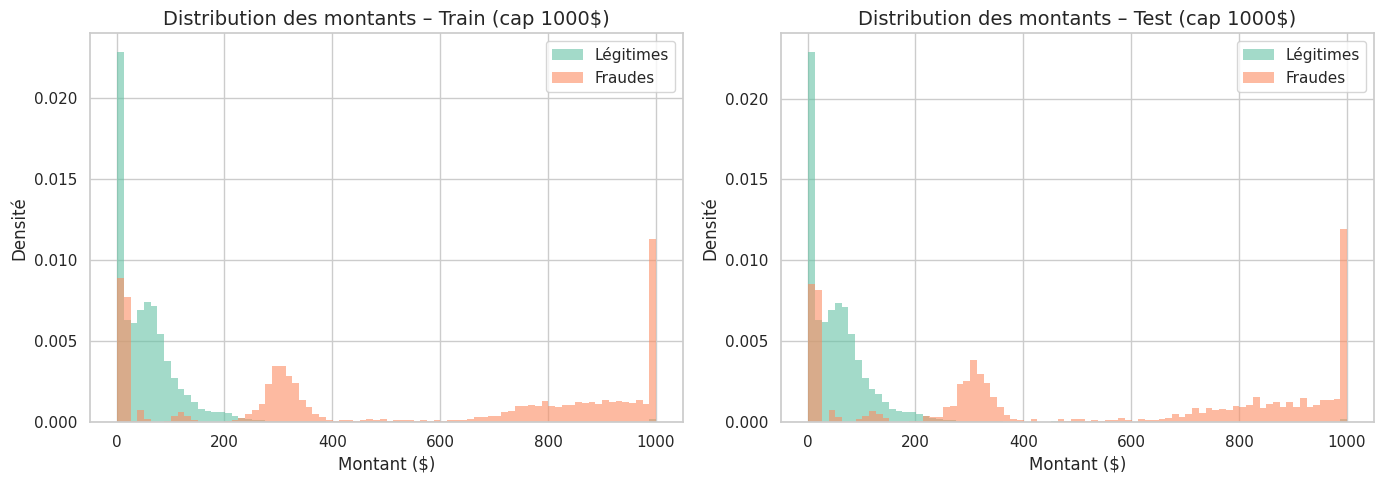

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name) in zip(axes, [(train, "Train"), (test, "Test")]):
    for label, grp in df.groupby("is_fraud"):
        tag = "Fraudes" if label == 1 else "Légitimes"
        ax.hist(
            grp["amt"].clip(upper=1000),
            bins=80,
            alpha=0.6,
            label=tag,
            density=True,
            edgecolor="none",
        )
    ax.set_title(f"Distribution des montants – {name} (cap 1000$)")
    ax.set_xlabel("Montant ($)")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Analyse par catégorie de marchand (`category`)

In [ ]:
cat_stats = (
    train.groupby("category")["is_fraud"]
    .agg(total="count", fraudes="sum")
    .assign(taux_fraude=lambda d: d["fraudes"] / d["total"] * 100)
    .sort_values("taux_fraude", ascending=False)
)
cat_stats

,total,fraudes,taux_fraude
category,,,
shopping_net,97543,1713,1.756149
misc_net,63287,915,1.445795
grocery_pos,123638,1743,1.409761
shopping_pos,116672,843,0.722538
gas_transport,131659,618,0.469394
misc_pos,79655,250,0.313853
grocery_net,45452,134,0.294817
travel,40507,116,0.286370
entertainment,94014,233,0.247835


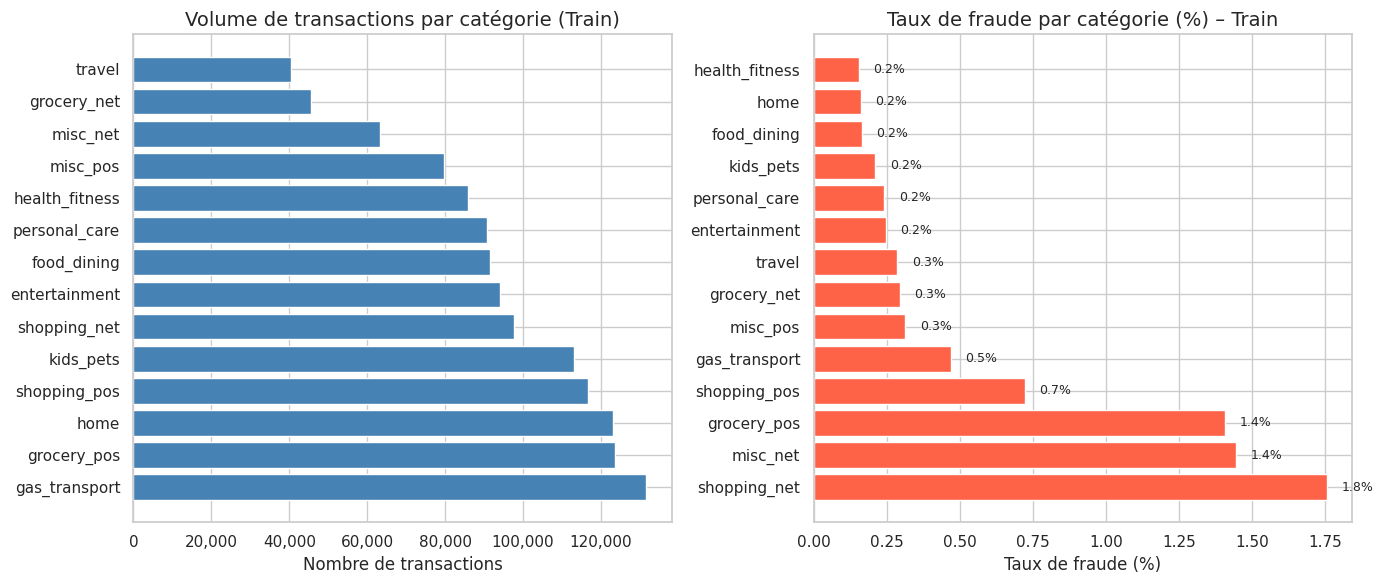

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cat_vol = train["category"].value_counts()
axes[0].barh(cat_vol.index, cat_vol.values, color="steelblue")
axes[0].set_title("Volume de transactions par catégorie (Train)")
axes[0].set_xlabel("Nombre de transactions")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].barh(cat_stats.index, cat_stats["taux_fraude"], color="tomato")
axes[1].set_title("Taux de fraude par catégorie (%) – Train")
axes[1].set_xlabel("Taux de fraude (%)")
for i, v in enumerate(cat_stats["taux_fraude"]):
    axes[1].text(v + 0.05, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Analyse temporelle

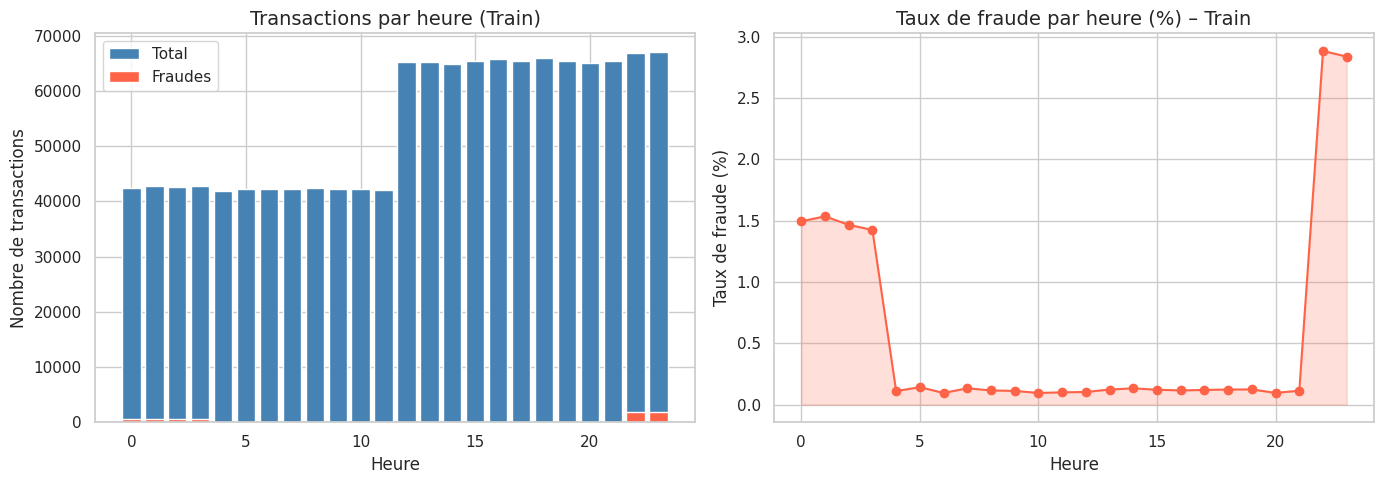

In [ ]:
train["hour"] = train["trans_date_trans_time"].dt.hour

hourly = train.groupby("hour")["is_fraud"].agg(total="count", fraudes="sum")
hourly["taux_fraude"] = hourly["fraudes"] / hourly["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly.index, hourly["total"], color="steelblue", label="Total")
axes[0].bar(hourly.index, hourly["fraudes"], color="tomato", label="Fraudes")
axes[0].set_title("Transactions par heure (Train)")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Nombre de transactions")
axes[0].legend()

axes[1].plot(hourly.index, hourly["taux_fraude"], marker="o", color="tomato")
axes[1].set_title("Taux de fraude par heure (%) – Train")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].fill_between(hourly.index, hourly["taux_fraude"], alpha=0.2, color="tomato")

plt.tight_layout()
plt.show()

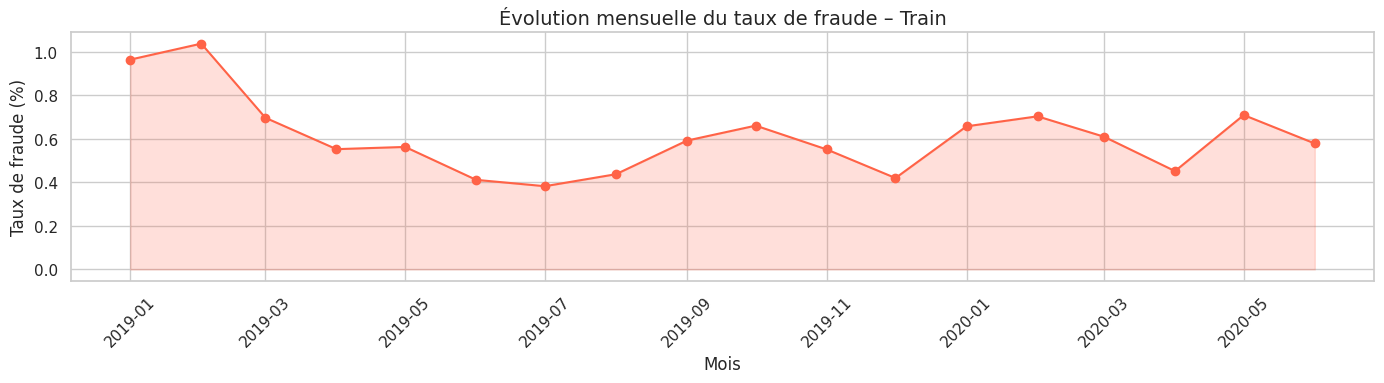

In [ ]:
train["month"] = train["trans_date_trans_time"].dt.to_period("M")

monthly = (
    train.groupby("month")["is_fraud"]
    .agg(total="count", fraudes="sum")
    .assign(taux_fraude=lambda d: d["fraudes"] / d["total"] * 100)
    .reset_index()
)
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly["month_dt"], monthly["taux_fraude"], marker="o", color="tomato")
ax.fill_between(monthly["month_dt"], monthly["taux_fraude"], alpha=0.2, color="tomato")
ax.set_title("Évolution mensuelle du taux de fraude – Train")
ax.set_xlabel("Mois")
ax.set_ylabel("Taux de fraude (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Analyse des profils clients

,total,fraudes,taux_fraude
Femmes (F),709863,3735,0.526158
Hommes (M),586812,3771,0.642625


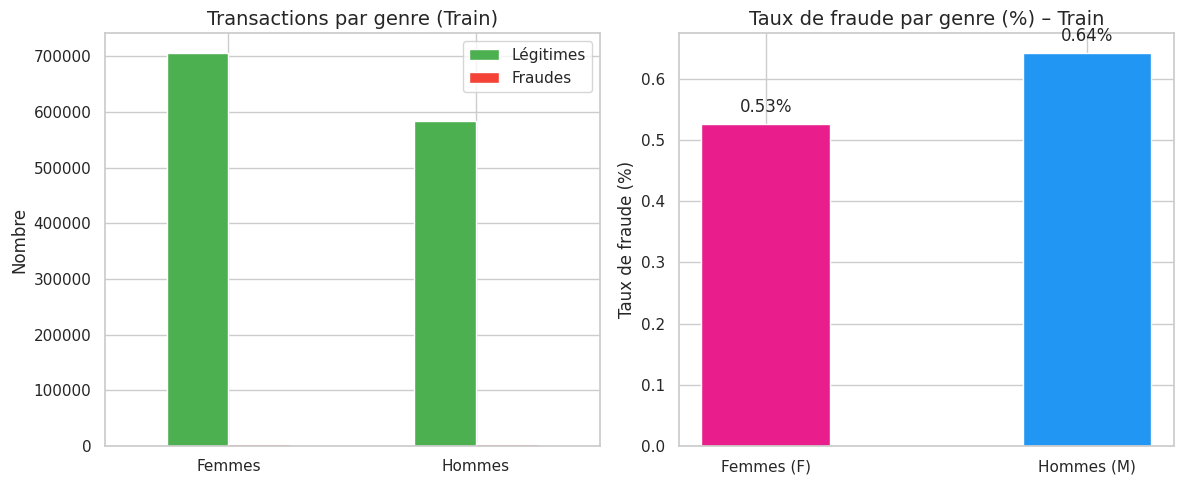

In [ ]:
gender_stats = (
    train.groupby("gender")["is_fraud"]
    .agg(total="count", fraudes="sum")
    .assign(taux_fraude=lambda d: d["fraudes"] / d["total"] * 100)
)
gender_stats.index = ["Femmes (F)", "Hommes (M)"]
display(gender_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_g = train.groupby(["gender", "is_fraud"]).size().unstack(fill_value=0)
counts_g.index = ["Femmes", "Hommes"]
counts_g.columns = ["Légitimes", "Fraudes"]
counts_g.plot(kind="bar", ax=axes[0], color=["#4caf50", "#f44336"], edgecolor="white")
axes[0].set_title("Transactions par genre (Train)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre")
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(
    gender_stats.index,
    gender_stats["taux_fraude"],
    color=["#e91e8c", "#2196f3"],
    width=0.4,
)
axes[1].set_title("Taux de fraude par genre (%) – Train")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(gender_stats["taux_fraude"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

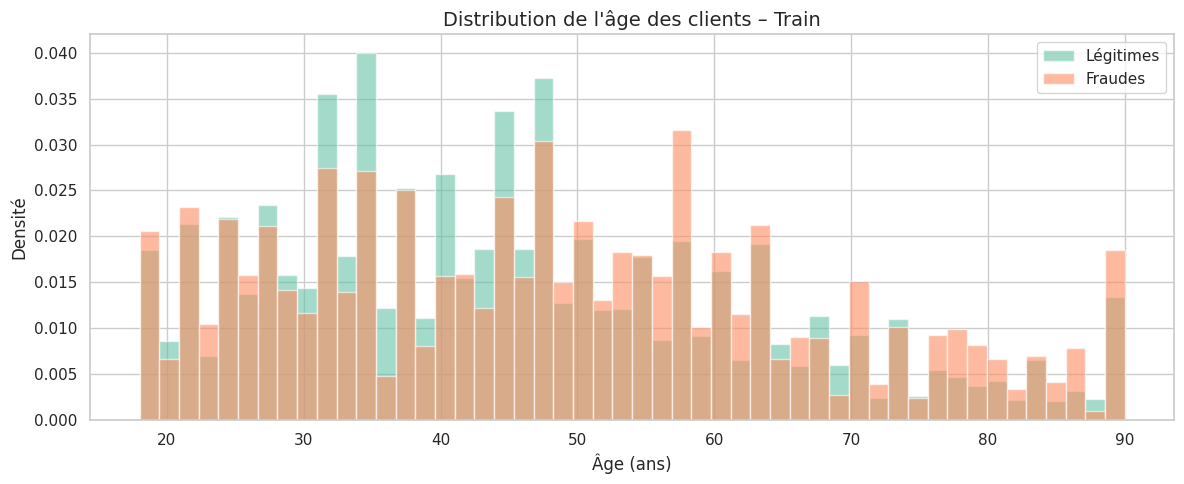

In [ ]:
train["age"] = (train["trans_date_trans_time"] - train["dob"]).dt.days // 365

fig, ax = plt.subplots(figsize=(12, 5))
for label, grp in train.groupby("is_fraud"):
    tag = "Fraudes" if label == 1 else "Légitimes"
    ax.hist(grp["age"].clip(18, 90), bins=50, alpha=0.6, label=tag, density=True)

ax.set_title("Distribution de l'âge des clients – Train")
ax.set_xlabel("Âge (ans)")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Distance entre client et marchand

,count,mean,std,min,25%,50%,75%,max
Légitimes,1289169.0,0.765652,0.284766,0.000239,0.564945,0.798321,0.977541,1.413364
Fraudes,7506.0,0.767281,0.281718,0.006658,0.567215,0.796925,0.976395,1.400695


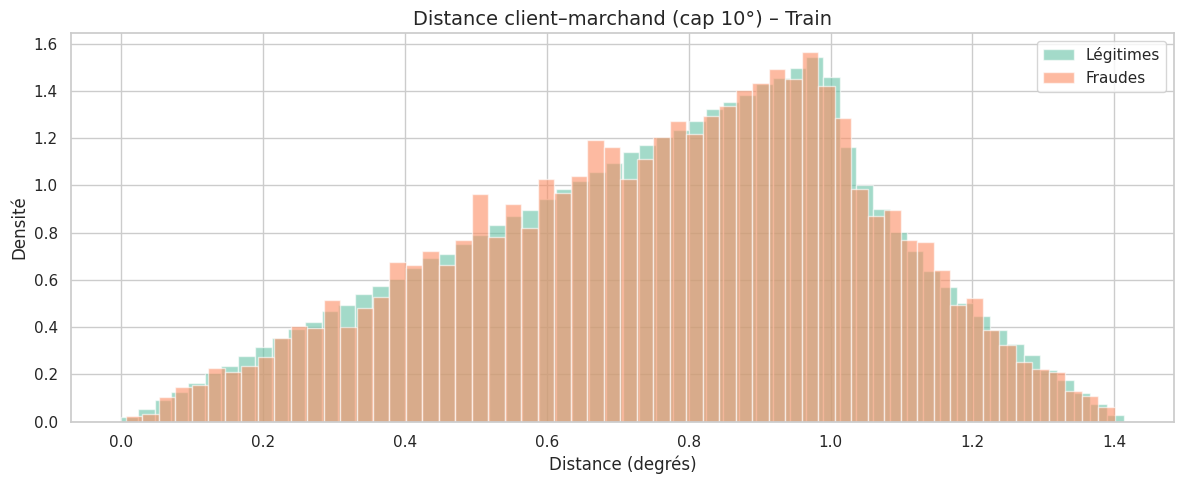

In [ ]:
train["distance"] = np.sqrt(
    (train["lat"] - train["merch_lat"]) ** 2
    + (train["long"] - train["merch_long"]) ** 2
)

dist_stats = train.groupby("is_fraud")["distance"].describe()
dist_stats.index = ["Légitimes", "Fraudes"]
display(dist_stats)

fig, ax = plt.subplots(figsize=(12, 5))
for label, grp in train.groupby("is_fraud"):
    tag = "Fraudes" if label == 1 else "Légitimes"
    ax.hist(grp["distance"].clip(upper=10), bins=60, alpha=0.6, label=tag, density=True)

ax.set_title("Distance client–marchand (cap 10°) – Train")
ax.set_xlabel("Distance (degrés)")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Corrélations (features numériques)

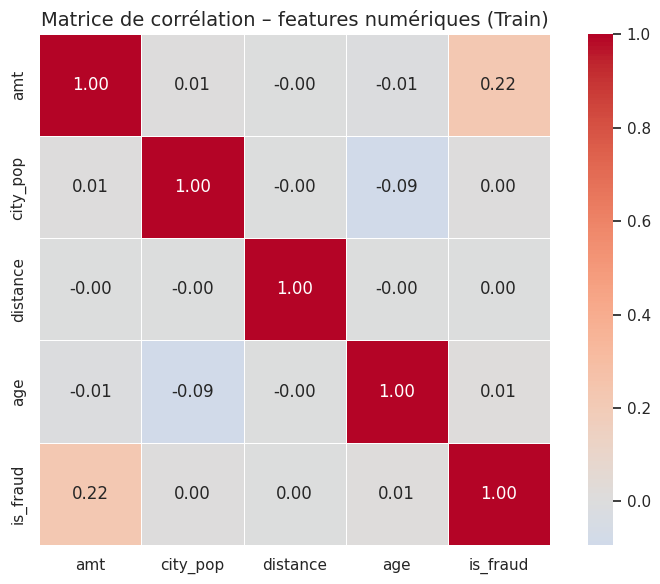

In [17]:
num_cols = ["amt", "city_pop", "distance", "age", "is_fraud"]
corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matrice de corrélation – features numériques (Train)")
plt.tight_layout()
plt.show()